In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar dataset
df = pd.read_csv('../datasets/Advertising.csv')

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [5]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

### **Correlación entre variables**

In [6]:
# Correlación entre las variables
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

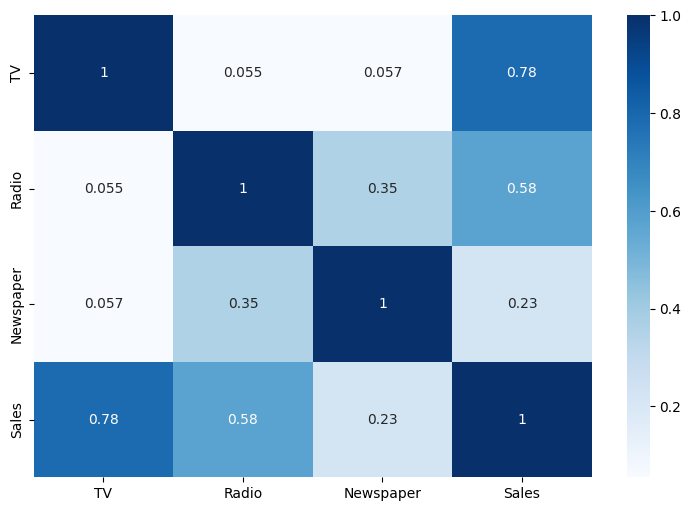

In [7]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues')

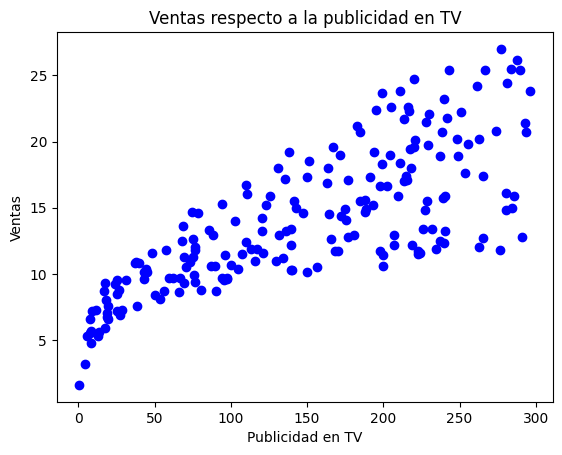

In [8]:
plt.plot(df['TV'], df['Sales'], 'bo')
plt.title('Ventas respecto a la publicidad en TV')
plt.xlabel('Publicidad en TV')
plt.ylabel('Ventas')
plt.show()

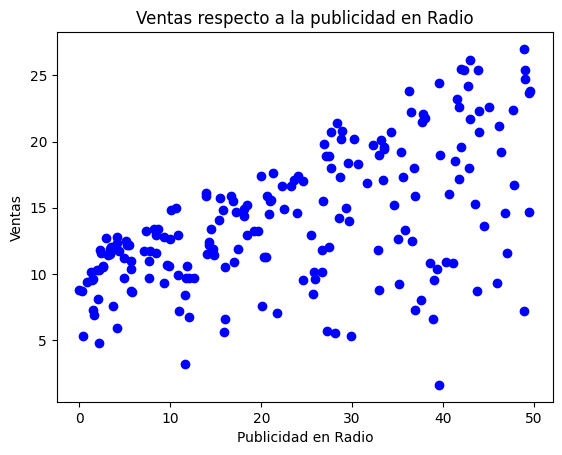

In [9]:
plt.plot(df['Radio'], df['Sales'], 'bo')
plt.title('Ventas respecto a la publicidad en Radio')
plt.xlabel('Publicidad en Radio')
plt.ylabel('Ventas')
plt.show()

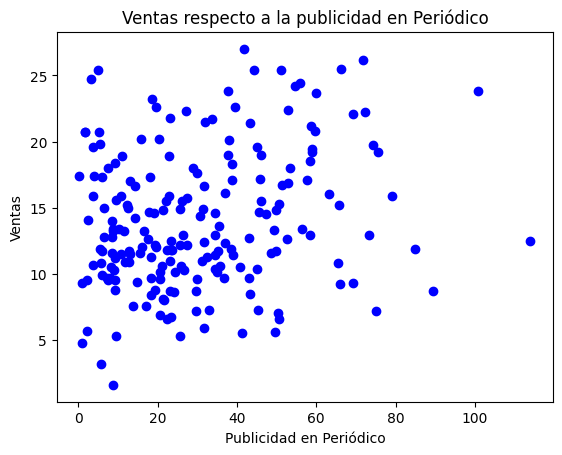

In [10]:
plt.plot(df['Newspaper'], df['Sales'], 'bo')
plt.title('Ventas respecto a la publicidad en Periódico')
plt.xlabel('Publicidad en Periódico')
plt.ylabel('Ventas')
plt.show()

### **Creación de los modelos de regresión lineal simple**

#### TV

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split # división de datos
from sklearn.metrics import mean_squared_error # medida de error cuadrático

In [12]:
data_tv = df[['TV']]

In [13]:
data_tv[0:5]

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8


In [14]:
# Variable dependiente
y = df['Sales'].values 

In [15]:
## División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(data_tv, y, test_size = 0.2, random_state = 42)
# random_state es la semilla para reproducir el mismo resultado
# 80% para entrenamiento y 20% para prueba

In [16]:
reg = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print('Intercepto: {:.2f}'.format(reg.intercept_))
print('Coeficiente: {:.2f}'.format(reg.coef_[0]))
print('Ecuación de la recta: Sales = {:.2f} + {:.2f} * TV'.format(reg.intercept_, reg.coef_[0]))

Intercepto: 7.12
Coeficiente: 0.05
Ecuación de la recta: Sales = 7.12 + 0.05 * TV


In [18]:
y_pred = reg.predict(X_test)
print('Predicciones: {}, \n Valores reales: {}'.format(y_pred[:5], y_test[:5]))

Predicciones: [14.71794394 16.2115484  20.74819743  7.66403631 17.37013877], 
 Valores reales: [16.9 22.4 21.4  7.3 24.7]


In [19]:
r_squared = reg.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('R-Squared:', r_squared)
print('MSE:', mse)
print('RMSE:', rmse)

R-Squared: 0.6766954295627076
MSE: 10.204654118800956
RMSE: 3.194472431998898


In [20]:
sales_comp = pd.DataFrame({
    "TV": X_test.values.flatten(),
    "Real Sales": y_test.flatten(),
    "Predicted Sales": y_pred.flatten()
})

sales_comp.head()

,TV,Real Sales,Predicted Sales
0,163.3,16.9,14.717944
1,195.4,22.4,16.211548
2,292.9,21.4,20.748197
3,11.7,7.3,7.664036
4,220.3,24.7,17.370139


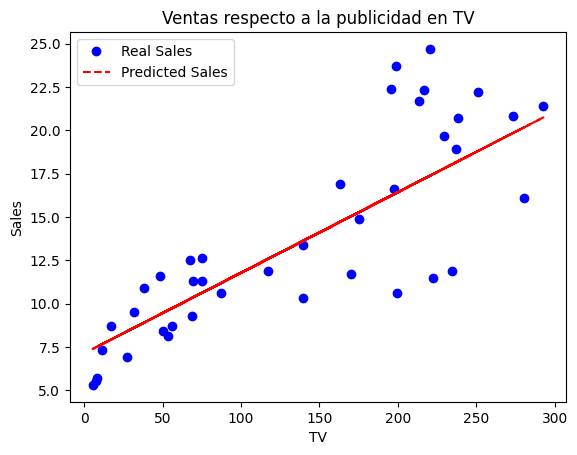

In [21]:
# Graficamos nuestro modelo junto a los datos de nuestro conjunto de testing
plt.plot(sales_comp['TV'], sales_comp['Real Sales'], 'bo', label='Real Sales')
plt.plot(sales_comp['TV'], sales_comp['Predicted Sales'], 'r--', label='Predicted Sales')
plt.title('Ventas respecto a la publicidad en TV')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend()
plt.show()

#### Radio

In [24]:
data_radio = df[['Radio']]

In [25]:
y = df["Sales"].values

X_train, X_test, y_train, y_test = train_test_split(data_radio, y, test_size = 0.2, random_state = 42)

In [27]:
reg_radio = LinearRegression()

reg_radio.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred_radio = reg_radio.predict(X_test)
print('Predicciones: {}, \n Valores reales: {}'.format(y_pred_radio[:5], y_test[:5]))

Predicciones: [15.88332197 19.17427219 15.20877938 16.96667826 19.44000109], 
 Valores reales: [16.9 22.4 21.4  7.3 24.7]


In [30]:
r_squared = reg_radio.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('R-Squared:', r_squared)
print('MSE:', mse)
print('RMSE:', rmse)

R-Squared: 0.2634309396999791
MSE: 10.204654118800956
RMSE: 3.194472431998898


In [34]:
sales_comp = pd.DataFrame({
    "Radio": X_test.values.flatten(),
    "Real Sales": y_test.flatten(),
    "Predicted Sales": y_pred_radio.flatten()
})

sales_comp.head()

,Radio,Real Sales,Predicted Sales
0,31.6,16.9,15.883322
1,47.7,22.4,19.174272
2,28.3,21.4,15.208779
3,36.9,7.3,16.966678
4,49.0,24.7,19.440001


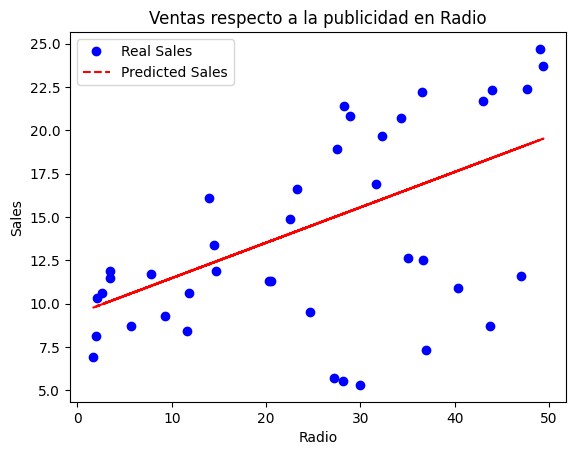

In [35]:
# Graficamos nuestro modelo junto a los datos de nuestro conjunto de testing
plt.plot(sales_comp['Radio'], sales_comp['Real Sales'], 'bo', label='Real Sales')
plt.plot(sales_comp['Radio'], sales_comp['Predicted Sales'], 'r--', label='Predicted Sales')
plt.title('Ventas respecto a la publicidad en Radio')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.legend()
plt.show()